# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika | 5054251050 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [16]:
# Import library yang dibutuhkan.
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
random_state = 42

In [17]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv("insurance.csv")

In [18]:
# Tampilkan beberapa baris pertama dataset.
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
# Tampilkan informasi dataset.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [20]:
# Periksa missing value.
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [22]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
categorical_features = df.select_dtypes(include=["object"]).columns
for feature in categorical_features:
    print(f"\nValue counts for feature '{feature}':")
    print(df[feature].value_counts())



Value counts for feature 'sex':
sex
male      676
female    662
Name: count, dtype: int64

Value counts for feature 'smoker':
smoker
no     1064
yes     274
Name: count, dtype: int64

Value counts for feature 'region':
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


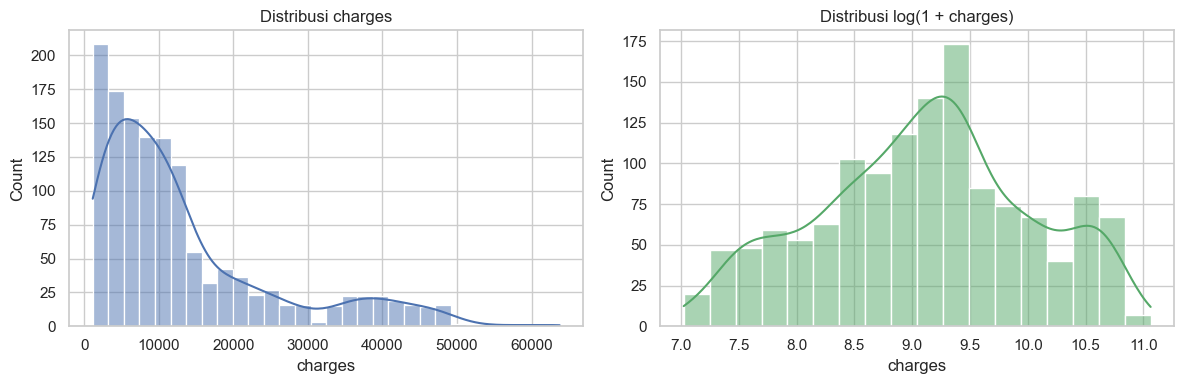

Skewness charges      : 1.516
Skewness log(charges) : -0.09


In [23]:
# Distribusi target 'charges'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribusi charges")
sns.histplot(np.log1p(df["charges"]), kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribusi log(1 + charges)")
plt.tight_layout(); plt.show()
print("Skewness charges      :", round(df["charges"].skew(), 3))
print("Skewness log(charges) :", round(np.log1p(df["charges"]).skew(), 3))

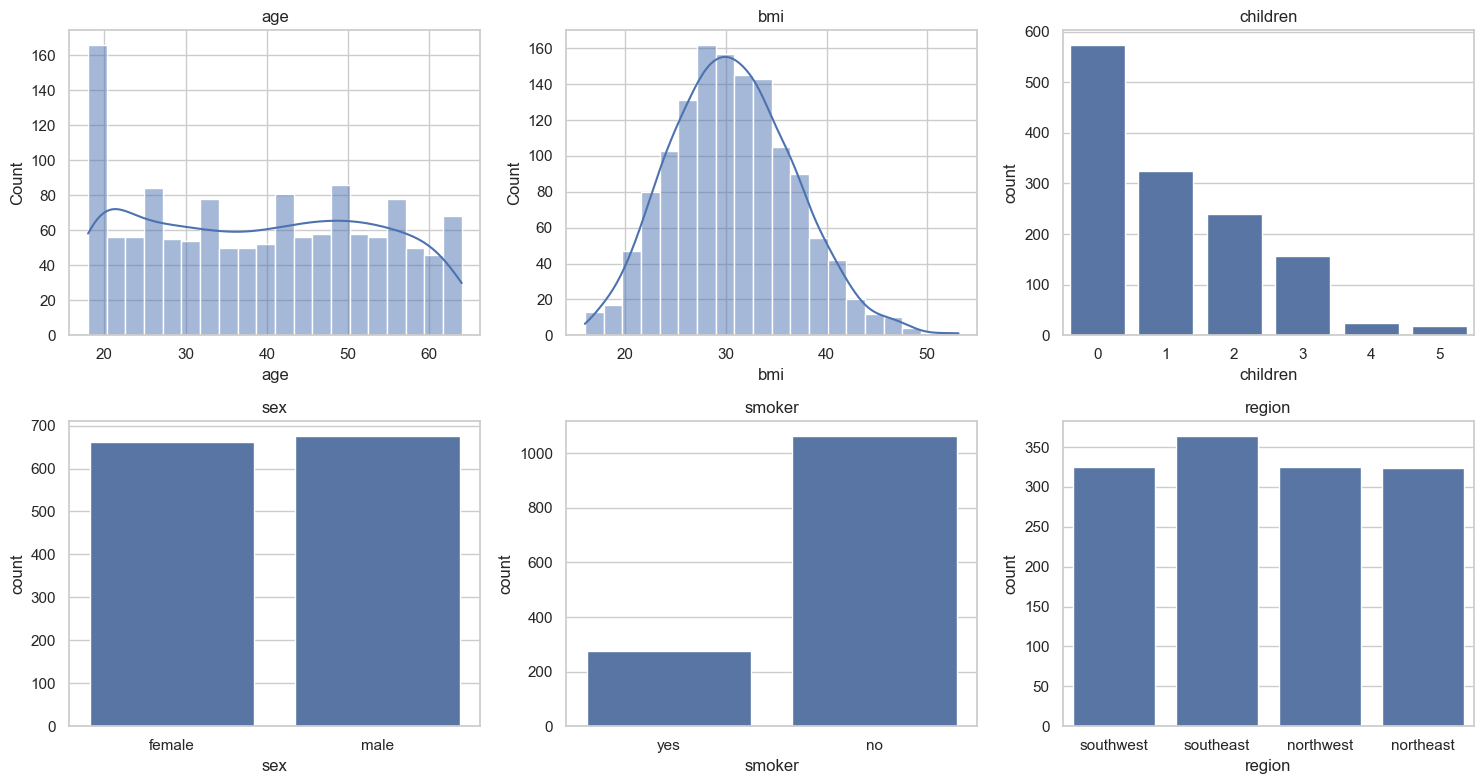

In [24]:
# Distribusi fitur
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0, 0]); axes[0, 0].set_title("age")
sns.histplot(df["bmi"], bins=20, kde=True, ax=axes[0, 1]); axes[0, 1].set_title("bmi")
sns.countplot(x="children", data=df, ax=axes[0, 2]); axes[0, 2].set_title("children")
sns.countplot(x="sex", data=df, ax=axes[1, 0]); axes[1, 0].set_title("sex")
sns.countplot(x="smoker", data=df, ax=axes[1, 1]); axes[1, 1].set_title("smoker")
sns.countplot(x="region", data=df, ax=axes[1, 2]); axes[1, 2].set_title("region")
plt.tight_layout(); plt.show()

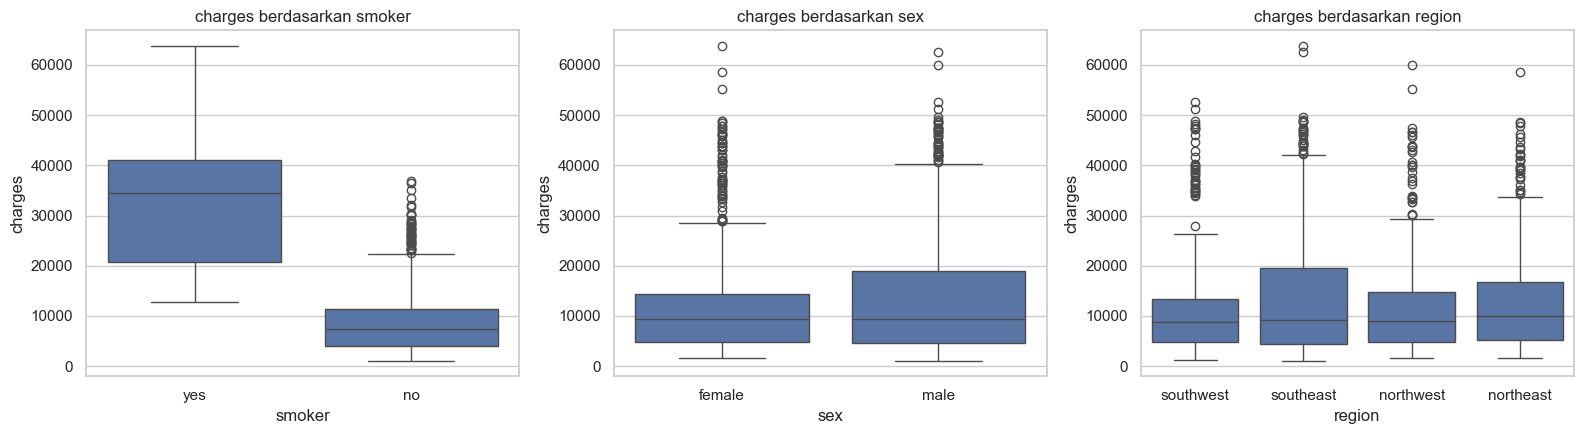

           mean   median      std
smoker                           
no       8434.3   7345.4   5993.8
yes     32050.2  34456.3  11541.5


In [25]:
# Hubungan fitur kategorikal dengan `charges`
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["smoker", "sex", "region"]):
    sns.boxplot(x=col, y="charges", data=df, ax=ax)
    ax.set_title(f"charges berdasarkan {col}")
plt.tight_layout(); plt.show()
print(df.groupby("smoker")["charges"].agg(["mean", "median", "std"]).round(1))

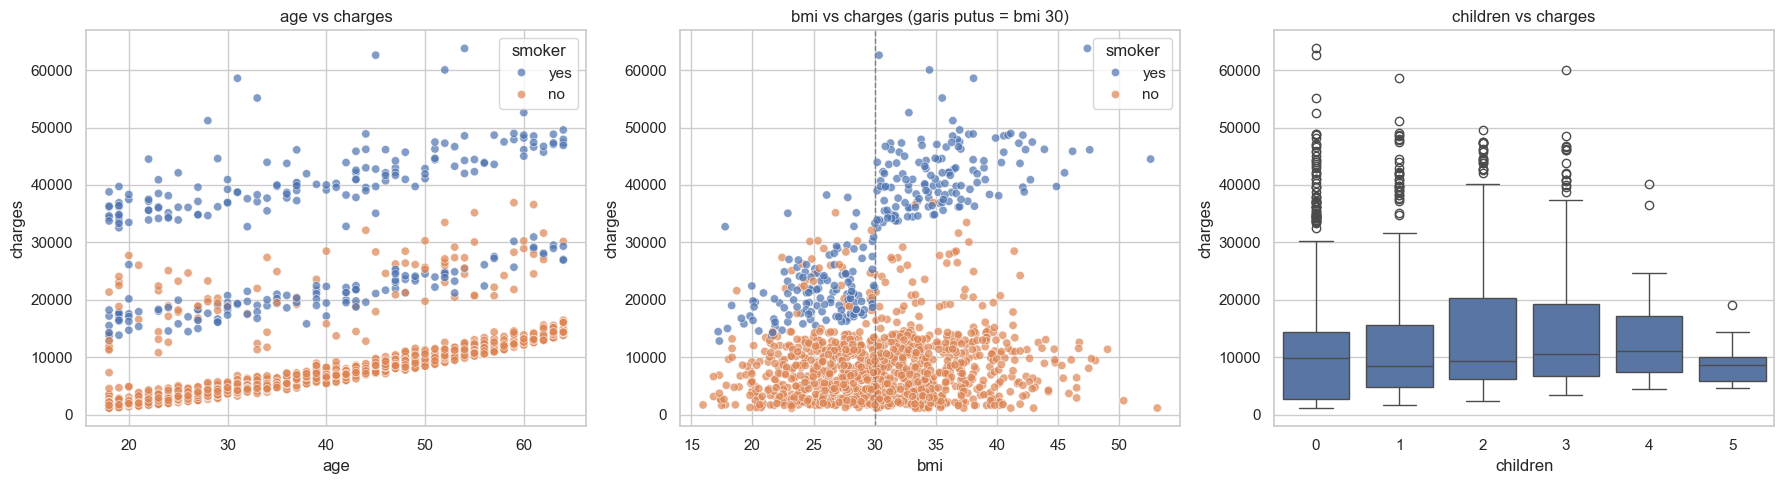

In [26]:
# Hubungan fitur numerik dengan `charges`
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=axes[0], alpha=0.7)
axes[0].set_title("age vs charges")
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=axes[1], alpha=0.7)
axes[1].axvline(30, color="gray", ls="--", lw=1)
axes[1].set_title("bmi vs charges (garis putus = bmi 30)")
sns.boxplot(x="children", y="charges", data=df, ax=axes[2])
axes[2].set_title("children vs charges")
plt.tight_layout(); plt.show()

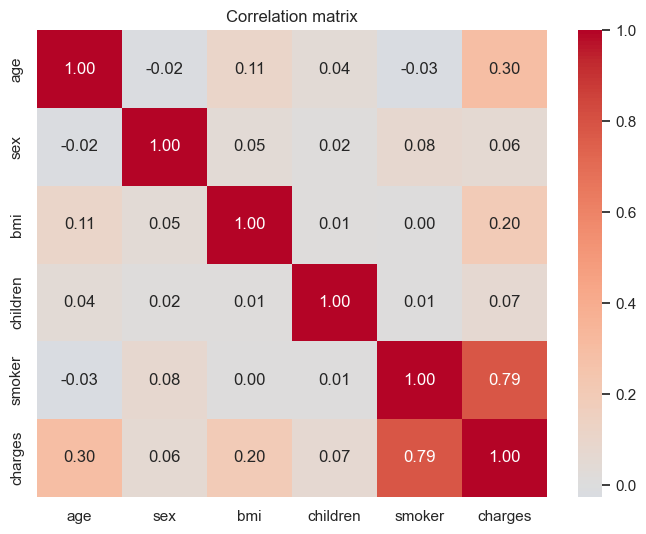

smoker      0.787
age         0.299
bmi         0.198
children    0.068
sex         0.057
Name: charges, dtype: float64


In [27]:
# Correlation matrix
corr_df = df.copy()
corr_df["smoker"] = (corr_df["smoker"] == "yes").astype(int)
corr_df["sex"] = (corr_df["sex"] == "male").astype(int)
corr = corr_df[["age", "sex", "bmi", "children", "smoker", "charges"]].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout(); plt.show()
print(corr["charges"].drop("charges").sort_values(ascending=False).round(3))

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [28]:
# Pisahkan fitur (X) dan target (y).
x_split = df.drop("charges", axis=1)
y_split = df["charges"]

In [29]:
# Identifikasi kolom numerik dan kategorikal.
numerical_features = x_split.select_dtypes(include=["int64", "float64"]).columns
categorical_features = x_split.select_dtypes(include=["object"]).columns
print("Numerik:", list(numerical_features))
print("Kategorikal:", list(categorical_features))

Numerik: ['age', 'bmi', 'children']
Kategorikal: ['sex', 'smoker', 'region']


In [30]:
# Bagi data menjadi train set dan test set.
train_x, test_x, train_y, test_y = train_test_split(
    x_split, y_split, test_size=0.2, random_state=random_state
)
print("Train:", train_x.shape, "| Test:", test_x.shape)

Train: (1070, 6) | Test: (268, 6)


In [31]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Gabungkan keduanya: numerik di-scaling, kategorikal di-One-Hot Encoding.
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

# Data untuk model yang membutuhkan scaling (Linear, Polynomial, Ridge, Lasso, SVR).
# fit hanya pada data train, data test cukup di-transform.
train_x_scaled = preprocessor.fit_transform(train_x)
test_x_scaled = preprocessor.transform(test_x)

# Data untuk Decision Tree: numerik tidak di-scaling, kategorikal tetap di-encode.
preprocessor_tree = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    ("cat", categorical_transformer, categorical_features),
])
train_x_tree = preprocessor_tree.fit_transform(train_x)
test_x_tree = preprocessor_tree.transform(test_x)

print("Bentuk data scaled:", train_x_scaled.shape, test_x_scaled.shape)
print("Nama kolom hasil preprocessing:")
print(list(preprocessor.get_feature_names_out()))

# Cross-validation 5-fold yang sama dipakai untuk eksperimen parameter di bagian 3.
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

Bentuk data scaled: (1070, 11) (268, 11)
Nama kolom hasil preprocessing:
['num__age', 'num__bmi', 'num__children', 'cat__sex_female', 'cat__sex_male', 'cat__smoker_no', 'cat__smoker_yes', 'cat__region_northeast', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [32]:
# Inisialisasi dan latih Linear Regression.
linear_regression_model = LinearRegression()
linear_regression_model.fit(train_x_scaled, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[3614.98,2036.23, 516.89,..., 88.91,-198.28,-350.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.031e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[34.92,32.9 ,30.63,..., 0. , 0. , 0. ]"


In [33]:
# Lakukan prediksi pada test set.
linear_predictions = linear_regression_model.predict(test_x_scaled)
print(linear_predictions[:10].round(2))

[ 8969.55  7068.75 36858.41  9454.68 26973.17 10864.11   170.28 16903.45
  1092.43 11218.34]


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [34]:
# Buat fitur polynomial dan latih model.
# Eksperimen degree dengan 5-fold cross-validation pada data train.
poly_rows = []
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    train_x_poly = poly.fit_transform(train_x_scaled)
    rmse = -cross_val_score(LinearRegression(), train_x_poly, train_y, cv=cv, scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(LinearRegression(), train_x_poly, train_y, cv=cv, scoring="r2")
    poly_rows.append({"degree": degree, "jumlah fitur": train_x_poly.shape[1], "CV RMSE": rmse.mean(), "CV R2": r2.mean()})
poly_cv = pd.DataFrame(poly_rows).round(4)
print(poly_cv)
best_degree = int(poly_cv.loc[poly_cv["CV RMSE"].idxmin(), "degree"])
print("Degree terbaik:", best_degree)

# Latih model dengan degree terbaik.
polynomial_features = PolynomialFeatures(degree=best_degree, include_bias=False)
train_x_poly = polynomial_features.fit_transform(train_x_scaled)
test_x_poly = polynomial_features.transform(test_x_scaled)

polynomial_model = LinearRegression()
polynomial_model.fit(train_x_poly, train_y)

   degree  jumlah fitur    CV RMSE   CV R2
0       1            11  6123.3538  0.7389
1       2            77  4887.2768  0.8331
2       3           363  5144.4144  0.8154
Degree terbaik: 2


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](77,)","[1614.1 ,2047.07, 321.08,...,-124.88, 0. , -50.59]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.005e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,77
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,36
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](77,)","[64.43,56.01,51.73,..., 0. , 0. , 0. ]"


In [35]:
# Lakukan prediksi pada test set.
polynomial_predictions = polynomial_model.predict(test_x_poly)
print(polynomial_predictions[:10].round(2))

[11215.72  6055.23 33306.27 10833.8  29082.43  4258.24  2803.16 16037.08
  4106.53 12147.43]


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [36]:
# Inisialisasi dan latih Ridge Regression.
# Alpha ditentukan lewat eksperimen (GridSearchCV).
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    cv=cv, scoring="neg_root_mean_squared_error",
)
ridge_grid.fit(train_x_scaled, train_y)
print("Alpha terbaik :", ridge_grid.best_params_)
print("CV RMSE       :", round(-ridge_grid.best_score_, 2))
ridge_model = ridge_grid.best_estimator_

Alpha terbaik : {'alpha': 0.1}
CV RMSE       : 6123.34


In [37]:
# Lakukan prediksi pada test set.
ridge_predictions = ridge_model.predict(test_x_scaled)
print(ridge_predictions[:10].round(2))

[ 8970.59  7069.84 36851.82  9456.05 26968.26 10865.45   172.19 16903.76
  1094.27 11219.52]


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [38]:
# Inisialisasi dan latih Lasso Regression.
# Alpha ditentukan lewat eksperimen (GridSearchCV).
lasso_grid = GridSearchCV(
    Lasso(max_iter=50000, random_state=random_state),
    param_grid={"alpha": [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]},
    cv=cv, scoring="neg_root_mean_squared_error",
)
lasso_grid.fit(train_x_scaled, train_y)
print("Alpha terbaik :", lasso_grid.best_params_)
print("CV RMSE       :", round(-lasso_grid.best_score_, 2))
lasso_model = lasso_grid.best_estimator_

# Koefisien Lasso (fitur dengan koefisien 0 dieliminasi).
feature_names = preprocessor.get_feature_names_out()
coef = pd.Series(lasso_model.coef_, index=feature_names).round(2)
print(coef.sort_values(key=abs, ascending=False))

Alpha terbaik : {'alpha': 50}
CV RMSE       : 6120.53
cat__smoker_no          -23335.17
num__age                  3568.84
num__bmi                  1952.66
num__children              474.28
cat__region_northeast      287.07
cat__region_southwest     -102.50
cat__sex_female             -0.00
cat__smoker_yes              0.00
cat__sex_male                0.00
cat__region_northwest        0.00
cat__region_southeast       -0.00
dtype: float64


In [39]:
# Lakukan prediksi pada test set.
lasso_predictions = lasso_model.predict(test_x_scaled)
print(lasso_predictions[:10].round(2))

[ 8827.94  7043.35 36468.61  9369.04 26679.88 10987.25   304.46 16695.75
  1185.77 11082.13]


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [40]:
# Inisialisasi dan latih Decision Tree Regressor.
# Memakai data tanpa scaling.
# max_depth dan min_samples_leaf ditentukan lewat eksperimen (GridSearchCV).
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=random_state),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_leaf": [1, 5, 10, 20, 30, 50],
    },
    cv=cv, scoring="neg_root_mean_squared_error",
)
tree_grid.fit(train_x_tree, train_y)
print("Parameter terbaik:", tree_grid.best_params_)
print("CV RMSE          :", round(-tree_grid.best_score_, 2))
tree_model = tree_grid.best_estimator_

# Pembanding: pohon tanpa batasan (default) untuk melihat overfitting.
tree_default = DecisionTreeRegressor(random_state=random_state).fit(train_x_tree, train_y)
print("\nDecision Tree default (tanpa batas) -> train R2 = %.4f | test R2 = %.4f" % (
    r2_score(train_y, tree_default.predict(train_x_tree)), r2_score(test_y, tree_default.predict(test_x_tree))))

Parameter terbaik: {'max_depth': 4, 'min_samples_leaf': 10}
CV RMSE          : 4580.51

Decision Tree default (tanpa batas) -> train R2 = 0.9983 | test R2 = 0.7028


In [41]:
# Lakukan prediksi pada test set.
tree_predictions = tree_model.predict(test_x_tree)
print(tree_predictions[:10].round(2))

[10662.68  5703.34 27503.01 10662.68 35031.66  5703.34  2757.95 15360.07
  5703.34 10662.68]


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [42]:
# Inisialisasi dan latih SVR.
# Pembanding: SVR default dengan target charges apa adanya.
svr_naive = SVR().fit(train_x_scaled, train_y)
print("SVR default tanpa scaling target -> test R2 = %.4f" % r2_score(test_y, svr_naive.predict(test_x_scaled)))

# SVR sensitif terhadap skala target (charges bernilai puluhan ribu), karena epsilon dan C
# bekerja pada skala target. Karena itu target (charges) juga di-scaling.
y_scaler = StandardScaler()
train_y_scaled = y_scaler.fit_transform(train_y.values.reshape(-1, 1)).ravel()

# Parameter ditentukan lewat eksperimen (GridSearchCV).
svr_grid = GridSearchCV(
    SVR(),
    param_grid={
        "kernel": ["rbf", "linear"],
        "C": [0.1, 1, 3, 10, 30, 100],
        "epsilon": [0.01, 0.1, 0.3],
        "gamma": ["scale", 0.05, 0.2],
    },
    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
svr_grid.fit(train_x_scaled, train_y_scaled)
svr_model = svr_grid.best_estimator_

# RMSE hasil CV masih dalam skala target yang sudah di-scaling; kalikan agar kembali ke satuan USD.
svr_cv_rmse = -svr_grid.best_score_ * y_scaler.scale_[0]
print("Parameter terbaik:", svr_grid.best_params_)
print("CV RMSE          :", round(svr_cv_rmse, 2))

SVR default tanpa scaling target -> test R2 = -0.0706
Parameter terbaik: {'C': 3, 'epsilon': 0.1, 'gamma': 0.05, 'kernel': 'rbf'}
CV RMSE          : 4785.49


In [43]:
# Lakukan prediksi pada test set.
# Prediksi SVR dikembalikan ke skala asli (USD).
def svr_predict(X):
    pred_scaled = svr_model.predict(X)
    return y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

svr_predictions = svr_predict(test_x_scaled)
print(svr_predictions[:10].round(2))

[ 9932.31  6230.38 30391.52  9903.3  26911.67  5144.43  3193.3  15124.19
  5339.67 11123.69]


# 4. Evaluasi Model

In [44]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.

# Prediksi (train, test) tiap model; train dipakai untuk melihat overfitting.
model_predictions = {
    "Linear Regression": (linear_regression_model.predict(train_x_scaled), linear_predictions),
    "Polynomial Regression": (polynomial_model.predict(train_x_poly), polynomial_predictions),
    "Ridge Regression": (ridge_model.predict(train_x_scaled), ridge_predictions),
    "Lasso Regression": (lasso_model.predict(train_x_scaled), lasso_predictions),
    "Decision Tree": (tree_model.predict(train_x_tree), tree_predictions),
    "SVR": (svr_predict(train_x_scaled), svr_predictions),
}

results = {}
predictions = {}
for name, (pred_train, pred_test) in model_predictions.items():
    predictions[name] = pred_test
    results[name] = {
        "MAE (test)": mean_absolute_error(test_y, pred_test),
        "MSE (test)": mean_squared_error(test_y, pred_test),
        "RMSE (test)": np.sqrt(mean_squared_error(test_y, pred_test)),
        "R2 (test)": r2_score(test_y, pred_test),
        "RMSE (train)": np.sqrt(mean_squared_error(train_y, pred_train)),
        "R2 (train)": r2_score(train_y, pred_train),
    }

results_df = pd.DataFrame(results).T.sort_values("RMSE (test)")
results_df["Gap R2 (train-test)"] = results_df["R2 (train)"] - results_df["R2 (test)"]
display(results_df.round(4))
print("Model terbaik berdasarkan RMSE test:", results_df.index[0])

,MAE (test),MSE (test),RMSE (test),R2 (test),RMSE (train),R2 (train),Gap R2 (train-test)
SVR,2407.9062,2.060097e+07,4538.8292,0.8673,4736.7226,0.8446,-0.0228
Polynomial Regression,2729.5001,2.071281e+07,4551.1324,0.8666,4778.1878,0.8418,-0.0248
Decision Tree,2697.7654,2.109348e+07,4592.7643,0.8641,4409.0973,0.8653,0.0012
Linear Regression,4181.1945,3.359692e+07,5796.2847,0.7836,6105.5452,0.7417,-0.0419
Ridge Regression,4181.7628,3.359919e+07,5796.4806,0.7836,6105.5458,0.7417,-0.0419
Lasso Regression,4216.1029,3.395739e+07,5827.2972,0.7813,6109.9216,0.7414,-0.0399


Model terbaik berdasarkan RMSE test: SVR


In [45]:
# Parameter terbaik hasil eksperimen + CV RMSE pada data train.
param_table = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression", "Ridge Regression", "Lasso Regression", "Decision Tree", "SVR"],
    "Parameter": [
        "-",
        f"degree={best_degree}",
        str(ridge_grid.best_params_),
        str(lasso_grid.best_params_),
        str(tree_grid.best_params_),
        str(svr_grid.best_params_),
    ],
    "CV RMSE (train)": [
        -cross_val_score(LinearRegression(), train_x_scaled, train_y, cv=cv, scoring="neg_root_mean_squared_error").mean(),
        poly_cv.loc[poly_cv["degree"] == best_degree, "CV RMSE"].iloc[0],
        -ridge_grid.best_score_, -lasso_grid.best_score_, -tree_grid.best_score_, svr_cv_rmse,
    ],
}).round(2)
display(param_table)

,Model,Parameter,CV RMSE (train)
0,Linear Regression,-,6123.35
1,Polynomial Regression,degree=2,4887.28
2,Ridge Regression,{'alpha': 0.1},6123.34
3,Lasso Regression,{'alpha': 50},6120.53
4,Decision Tree,"{'max_depth': 4, 'min_samples_leaf': 10}",4580.51
5,SVR,"{'C': 3, 'epsilon': 0.1, 'gamma': 0.05, 'kerne...",4785.49


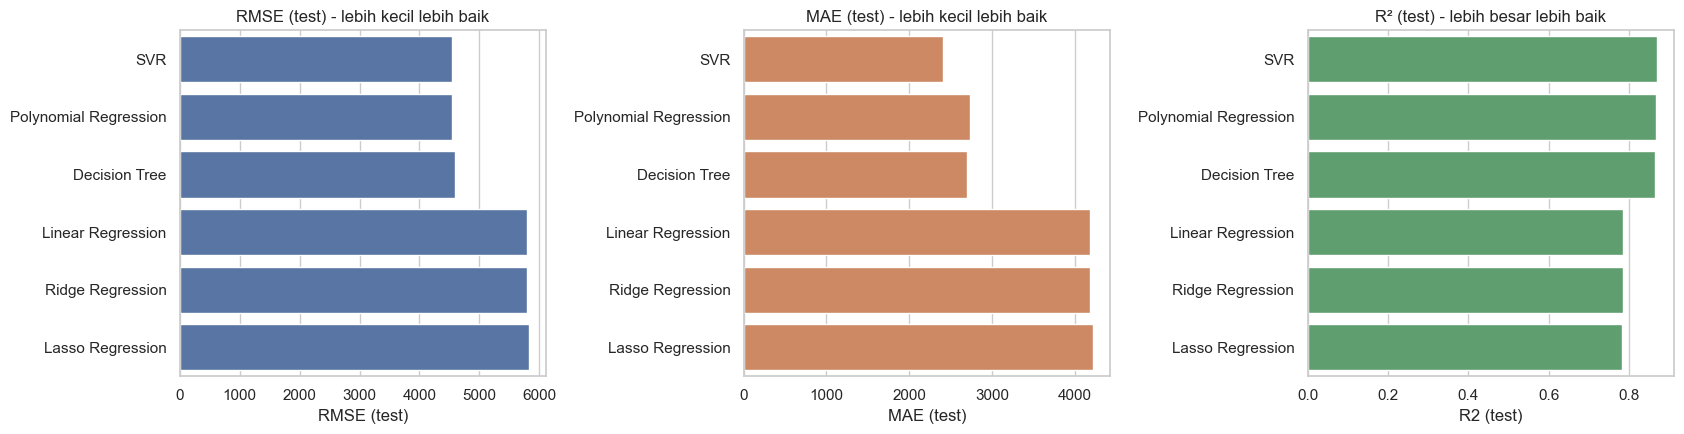

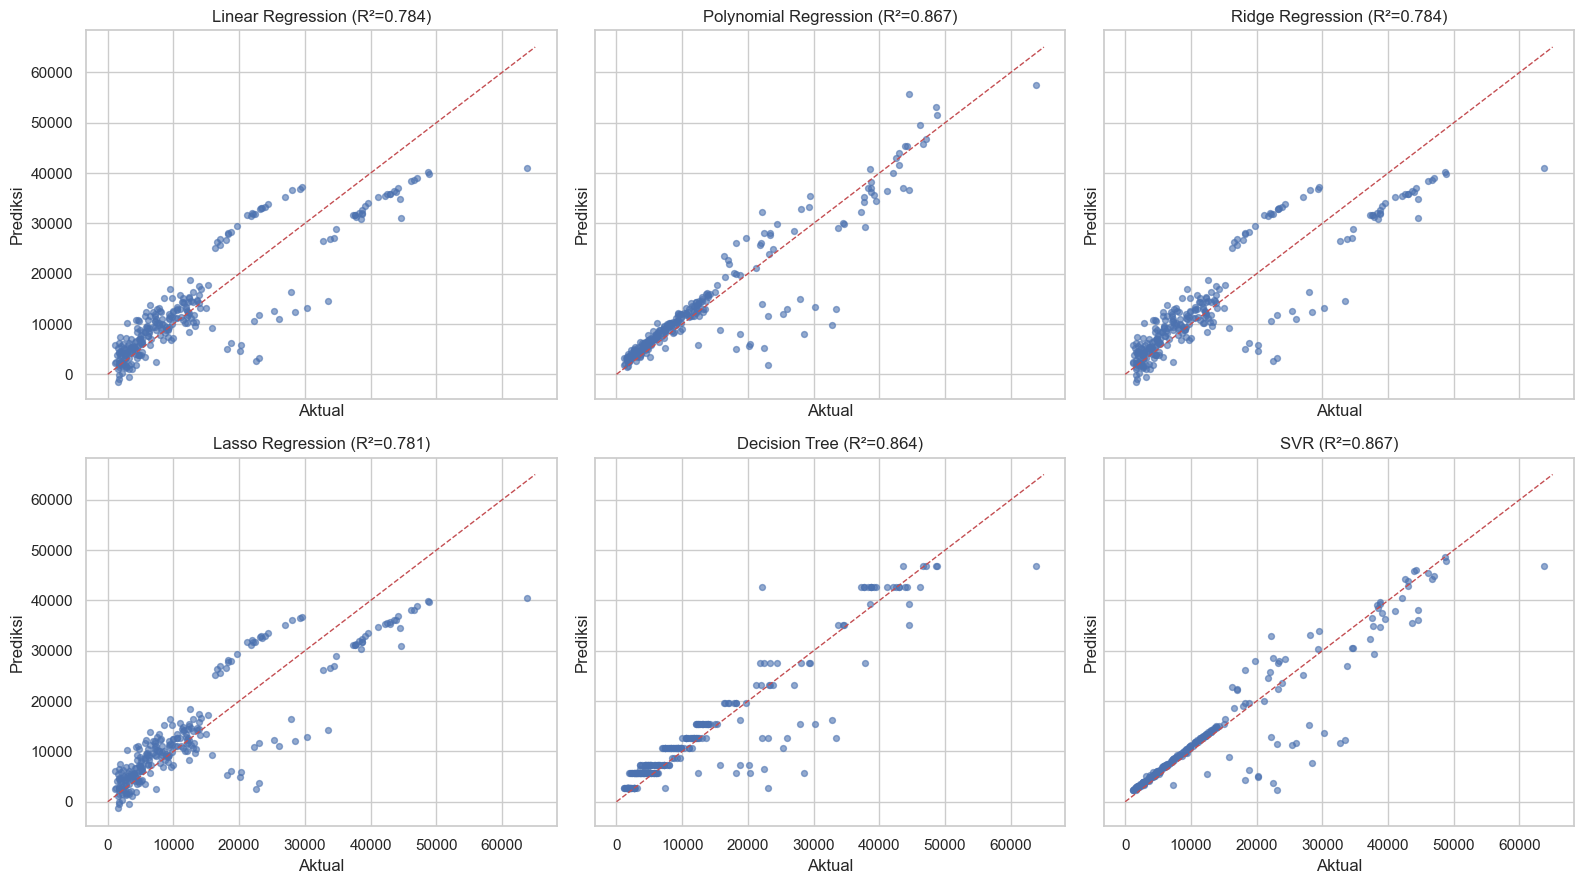

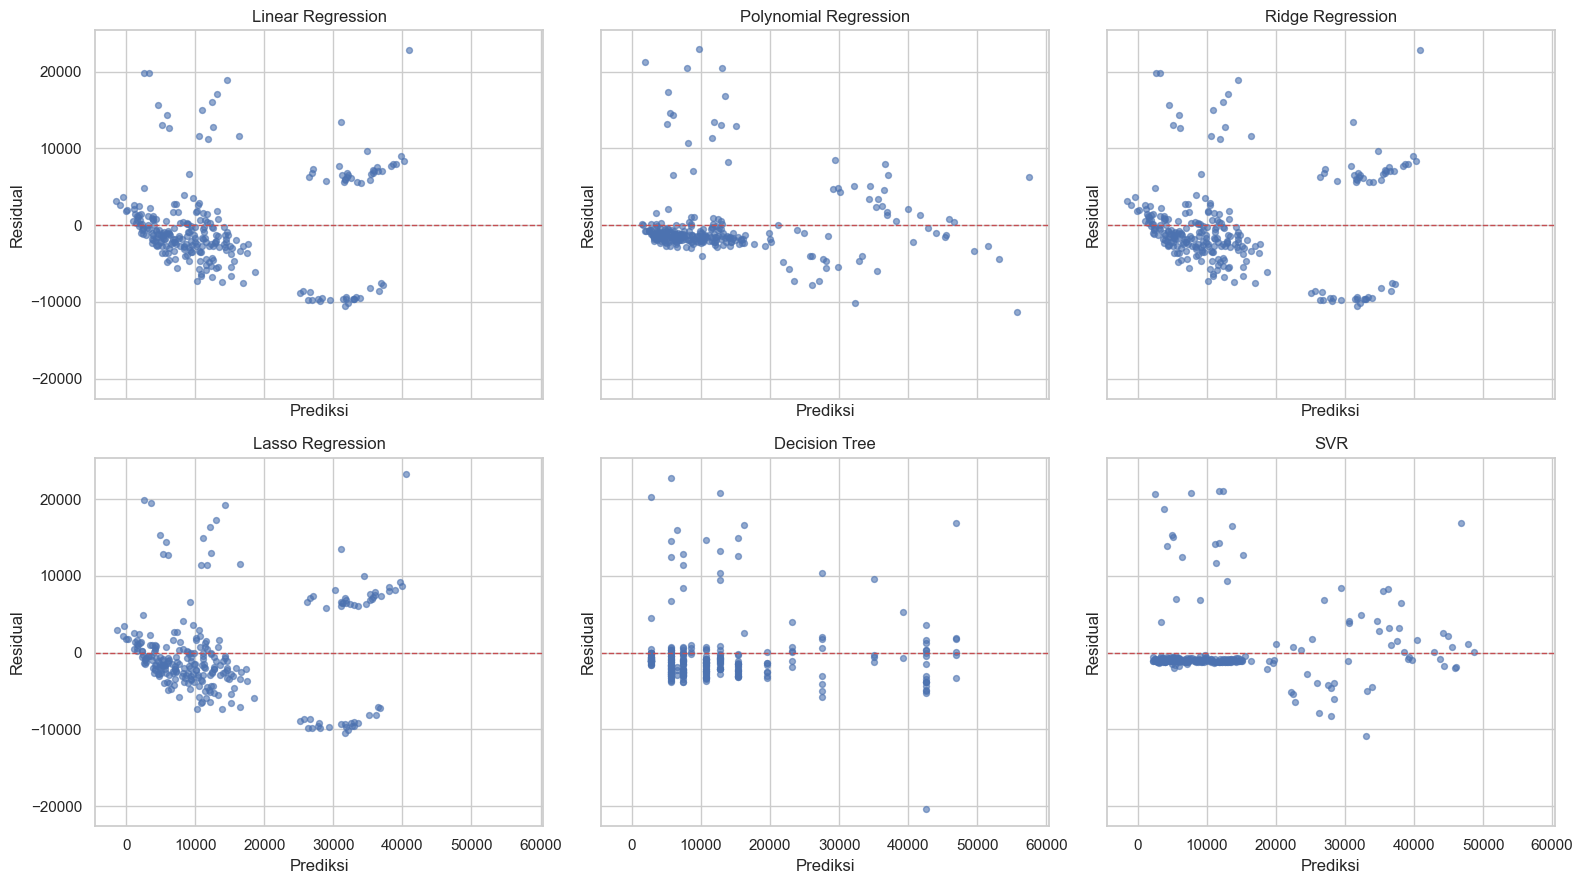

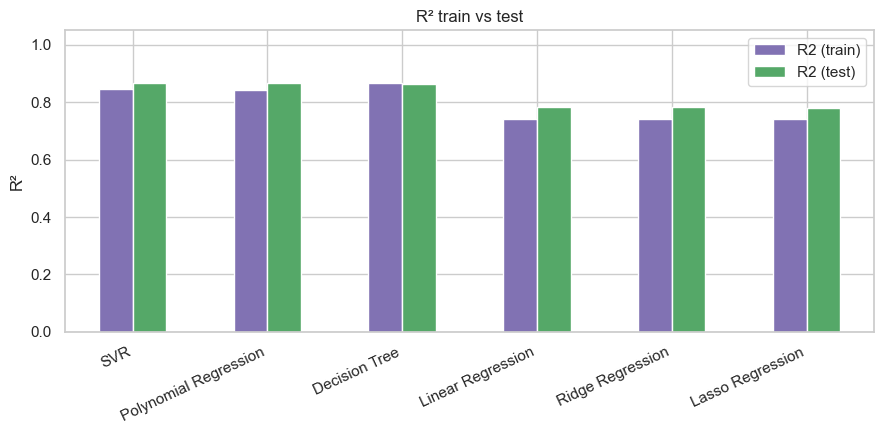

In [46]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.

# 1) Perbandingan metrik antar model.
order = results_df.index
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.barplot(x=results_df["RMSE (test)"], y=order, ax=axes[0], color="#4C72B0"); axes[0].set_title("RMSE (test) - lebih kecil lebih baik")
sns.barplot(x=results_df["MAE (test)"], y=order, ax=axes[1], color="#DD8452"); axes[1].set_title("MAE (test) - lebih kecil lebih baik")
sns.barplot(x=results_df["R2 (test)"], y=order, ax=axes[2], color="#55A868"); axes[2].set_title("R² (test) - lebih besar lebih baik")
for ax in axes: ax.set_ylabel("")
plt.tight_layout(); plt.show()

# 2) Nilai aktual vs prediksi pada test set.
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
lim = [0, max(test_y.max(), max(p.max() for p in predictions.values())) * 1.02]
for ax, name in zip(axes.ravel(), results.keys()):
    ax.scatter(test_y, predictions[name], alpha=0.6, s=18)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_title(f"{name} (R²={results[name]['R2 (test)']:.3f})")
    ax.set_xlabel("Aktual"); ax.set_ylabel("Prediksi")
plt.tight_layout(); plt.show()

# 3) Plot residual (aktual - prediksi) tiap model.
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), results.keys()):
    ax.scatter(predictions[name], test_y - predictions[name], alpha=0.6, s=18)
    ax.axhline(0, color="r", ls="--", lw=1)
    ax.set_title(name); ax.set_xlabel("Prediksi"); ax.set_ylabel("Residual")
plt.tight_layout(); plt.show()

# 4) R² train vs test (indikator overfitting).
results_df[["R2 (train)", "R2 (test)"]].plot(kind="bar", figsize=(9, 4.5), color=["#8172B3", "#55A868"])
plt.title("R² train vs test"); plt.ylabel("R²"); plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


**Jawab:**

### Perbandingan hasil (test set, 268 data)

| Model | MAE | RMSE | R² test | R² train |
|---|---|---|---|---|
| SVR (rbf, C=3, gamma=0.05) | **2.408** | **4.539** | **0.867** | 0.845 |
| Polynomial Regression (degree=2) | 2.730 | 4.551 | 0.867 | 0.842 |
| Decision Tree (max_depth=4, min_samples_leaf=10) | 2.698 | 4.593 | 0.864 | 0.865 |
| Linear Regression | 4.181 | 5.796 | 0.784 | 0.742 |
| Ridge Regression (alpha=0.1) | 4.182 | 5.796 | 0.784 | 0.742 |
| Lasso Regression (alpha=50) | 4.216 | 5.827 | 0.781 | 0.741 |


1. Model linear (Linear, Ridge, Lasso): R² ≈ 0.78, RMSE ≈ 5.8 ribu. Ketiganya praktis identik. Dataset hanya punya 1070 data latih dengan 11 fitur hasil encoding, sehingga model linear tidak overfit (gap train–test kecil) dan regularisasi hampir tidak memberi manfaat. Ridge dengan alpha optimal 0.1 hampir sama dengan OLS, dan Lasso (alpha 50) justru sedikit lebih buruk karena menyusutkan koefisien tanpa ada masalah varians yang perlu dikurangi. Lasso hanya menyisakan `age`, `bmi`, `children`, `smoker` dan sedikit `region`, serta menghilangkan `sex`, sejalan dengan EDA bahwa `sex` hampir tidak berpengaruh. Catatan: karena One-Hot Encoding menghasilkan kolom yang saling kolinear (`smoker_no` = 1 − `smoker_yes`), Lasso hanya memilih salah satu kolom, sehingga koefisien `smoker_no` besar sementara `smoker_yes` bernilai 0. Informasinya tetap sama.
2. Model non-linear (Polynomial, Decision Tree, SVR): R² ≈ 0.86–0.87, RMSE ≈ 4.5–4.6 ribu, turun sekitar 21% dari RMSE model linear. Ini sesuai temuan EDA: efek `smoker` × `bmi` dan pola `age` tidak bisa ditangkap oleh model aditif linear. Perbedaan antar ketiganya sangat kecil (RMSE hanya selisih ±50 USD), jadi tidak bisa dikatakan satu model jauh lebih unggul hanya dari satu split test. Pada 5-fold CV di data latih, Decision Tree justru terbaik (CV RMSE ≈ 4.581), diikuti SVR (≈ 4.787) dan Polynomial (≈ 4.887). SVR unggul jelas di MAE (2.408 vs ±2.700), artinya prediksinya paling dekat pada kasus tipikal.

### Pengaruh preprocessing:

- Scaling (StandardScaler) penting bagi SVR dan wajar bagi model linear yang diregularisasi (Ridge/Lasso) karena penalti bergantung pada besar koefisien. Untuk Linear/Polynomial murni scaling tidak mengubah prediksi, hanya membuat koefisien sebanding. Decision Tree tidak memerlukannya, sehingga dilatih dengan data numerik asli.
- Scaling target pada SVR: SVR default (tanpa scaling target) hanya menghasilkan R² = -0.07, lebih buruk daripada menebak rata-rata, karena `epsilon` dan `C` bekerja pada skala target yang bernilai puluhan ribu. Dengan `TransformedTargetRegressor` R² naik menjadi 0.867. Ini contoh jelas bahwa preprocessing bisa mengubah hasil secara drastis.
- One-Hot Encoding diperlukan karena `sex`, `smoker`, dan `region` bertipe teks. `handle_unknown="ignore"` mencegah error bila muncul kategori baru.
- `random_state` pada split membuat hasil reproducible dan perbandingan antar model adil karena semua dievaluasi pada data test yang sama.

### Pengaruh parameter:

- Polynomial degree: degree 1 (CV RMSE 6.123) → degree 2 (4.887) → degree 3 (5.144). Degree 2 optimal; degree 3 mulai overfit karena fiturnya melonjak (dari 77 menjadi 363 kolom pada 1070 data).
- Decision Tree: pohon tanpa batas overfit parah (R² train 0.998 vs test 0.703). Dengan `max_depth=4` dan `min_samples_leaf=10`, R² test naik menjadi 0.864 dan gap train–test hilang (0.865 vs 0.864). Pembatasan kompleksitas adalah faktor terpenting untuk pohon.
- SVR: kernel `rbf` mengalahkan `linear`; `C=3` dan `gamma=0.05` memberi keseimbangan. C yang terlalu besar membuat model mengejar outlier biaya tinggi.
- Ridge/Lasso: alpha optimal Ridge kecil (0.1), menandakan data tidak butuh regularisasi kuat.

### Keterbatasan:
- Semua model masih kesulitan pada biaya sangat tinggi (plot residual melebar di sisi prediksi besar), konsisten dengan distribusi charges yang miring dan jumlah kasus ekstrem yang sedikit.
- Evaluasi test hanya 268 data, sehingga selisih kecil antar Polynomial, Decision Tree, dan SVR tidak signifikan secara praktis.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


**Jawab:**

### Kesimpulan

- Model non-linear (SVR, Polynomial degree 2, Decision Tree) jauh lebih baik daripada model linear: R² test ≈ 0.86–0.87 dibanding ≈ 0.78, dan RMSE turun dari ≈ 5.8 ribu menjadi ≈ 4.5 ribu USD.
- Berdasarkan test set, SVR terbaik (RMSE 4.539, MAE 2.408, R² 0.867). Namun selisihnya dengan Polynomial dan Decision Tree sangat tipis; Decision Tree bahkan terbaik pada cross-validation dan paling mudah diinterpretasi. Pilihan akhir bisa disesuaikan kebutuhan: akurasi (SVR) atau interpretabilitas (Decision Tree).
- Ridge dan Lasso tidak memperbaiki Linear Regression karena model linear tidak overfit pada dataset ini. Lasso berguna untuk seleksi fitur, yaitu menegaskan sex dan sebagian region hampir tidak berkontribusi.
- Faktor terpenting biaya medis adalah status perokok, lalu usia dan BMI, dengan interaksi kuat antara merokok dan BMI ≥ 30.
- Preprocessing dan tuning sangat berpengaruh: scaling target menyelamatkan SVR (R² -0.07 → 0.867), pembatasan kedalaman menyelamatkan Decision Tree (R² test 0.703 → 0.864), dan degree 2 adalah titik optimal Polynomial.

### Saran

- Tambahkan fitur interaksi eksplisit, misalnya smoker × bmi atau indikator bmi ≥ 30 ke model linear/Ridge. Ini kemungkinan mendekatkan performanya ke model non-linear dengan tetap interpretable.
- Coba transformasi log pada target (log(charges)) agar residual lebih stabil, lalu kembalikan prediksi ke skala asli.
- Coba model ensemble (Random Forest, Gradient Boosting) yang umumnya kuat pada data tabular dengan interaksi.
- Gunakan repeated K-fold atau nested cross-validation untuk perbandingan yang lebih stabil, serta Randomized/Bayesian search untuk ruang parameter yang lebih luas.
- Laporkan juga interval ketidakpastian prediksi, karena error pada biaya tinggi masih besar.